## Import all the Dependencies

In [40]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import concatenate

## Set all the Constants

In [42]:
BATCH_SIZE = 32
IMAGE_SIZE = 224
LEARNING_RATE = 1e-4
EPOCHS=20


## Import data into tensorflow dataset object
We will use image_dataset_from_directory api to load all images in tensorflow dataset: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

In [44]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [46]:
# Get class names from the dataset
class_names = dataset.class_names
# Print dataset info
print(f"Class Names: {class_names}")
print(f"Total Classes: {len(class_names)}")

# Count images in each class
image_count = {class_name: 0 for class_name in class_names}

for _, labels_batch in dataset.unbatch():
    image_count[class_names[labels_batch.numpy()]] += 1

# Print image counts
print("\nNumber of images per class:")
for class_name, count in image_count.items():
    print(f"{class_name}: {count} images")

# Print total number of images
total_images = sum(image_count.values())
print(f"\nTotal Number of Images: {total_images}")



Class Names: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Total Classes: 3

Number of images per class:
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images
Potato___healthy: 152 images

Total Number of Images: 2152


In [50]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 224, 224, 3)
[1 1 0 1 0 1 1 1 1 0 2 1 1 0 1 0 0 1 0 0 1 1 1 2 1 0 1 1 1 0 0 0]


## Visualize some of the images from our dataset

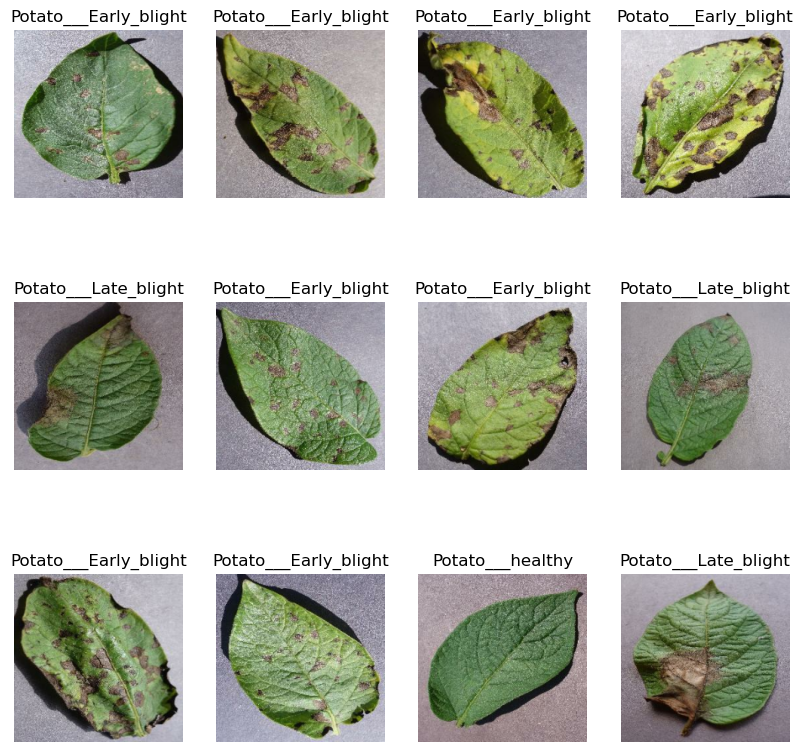

In [52]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

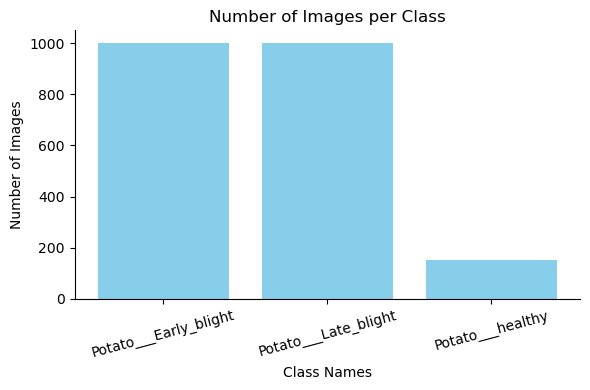

In [54]:
image_count = {class_name: 0 for class_name in class_names}

# Count the number of images for each class
for _, labels_batch in dataset.unbatch():
    image_count[class_names[labels_batch.numpy()]] += 1

# Plot the bar graph
plt.figure(figsize=(6, 4))  # Larger figure size
plt.bar(image_count.keys(), image_count.values(), color='skyblue', edgecolor=None)  # No bar outline
plt.xlabel('Class Names')
plt.ylabel('Number of Images')
plt.title('Number of Images per Class')
plt.xticks(rotation=15)

# Remove the spines (despine)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optimize layout
plt.tight_layout()

# Show the plot
plt.show()



## Function to Split Dataset
##### Dataset should be bifurcated into 3 subsets, namely:
    1. Training: Dataset to be used while training
    2. Validation: Dataset to be tested against while training
  #####    3. Test: Dataset to be tested against after we trained a model

In [56]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds




In [58]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [60]:
print(f"Training set: {len(train_ds)}")
print(f"Validation set: {len(val_ds)}")
print(f"Test set: {len(test_ds)}")

Training set: 54
Validation set: 6
Test set: 8


### Cache, Shuffle, and Prefetch the Dataset

In [62]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


## Building the Model
#### Creating a Layer for Resizing and Normalization
Before feeding images into the neural network, it's important to resize them to the desired size (e.g., 224x224) and normalize the pixel values by dividing by 224 to scale them between 0 and 1. Even if your training images are already the correct size, resizing ensures that any new image used for predictions will automatically fit the model. Adding these steps as a layer in the Sequential model makes the process seamless, applying resizing and normalization during both training and inference for better performance and consistency.

In [64]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])


#### Data Augmentation
Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.

In [66]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2)
])


#### Applying Data Augmentation to Train Dataset

In [68]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [70]:

# Fusion Model for Multi-Class Classification (3 Classes) with weights= imagenet
def build_fusion_model(num_classes, input_shape=(224, 224, 3), dropout_rate=0.5):
    input_layer = Input(shape=input_shape)

    # EfficientNetB0 with weights=None
    efficient_net = EfficientNetB0(include_top=False, input_tensor=input_layer, weights='imagenet')
    for layer in efficient_net.layers[:10]:  # Freeze first 10 layers 
        layer.trainable = False
    efficient_output = GlobalAveragePooling2D()(efficient_net.output)

    # InceptionV3 with weights=None
    inception_v3 = InceptionV3(include_top=False, input_tensor=input_layer, weights='imagenet')
    for layer in inception_v3.layers[:10]:  # Freeze first 10 layers
        layer.trainable = False
    inception_output = GlobalAveragePooling2D()(inception_v3.output)

    # Concatenate outputs
    combined_output = concatenate([efficient_output, inception_output])

    # Fully connected layers with dropout
    x = Dense(256, activation='relu')(combined_output)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout_rate)(x)

    # Output Layer for Multi-Class Classification
    output_layer = Dense(num_classes, activation='softmax')(x)  # num_classes neurons with softmax activation
        
    model = Model(inputs=input_layer, outputs=output_layer)
    return model



In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# Function to create callbacks
def create_callbacks(checkpoint_path):
    # ModelCheckpoint: Save the best model based on validation loss
    checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_path,  # Path to save the model
        monitor='val_loss',        # Metric to monitor
        save_best_only=True,       # Save only the best model
        mode='min',                # Minimize val_loss
        verbose=1                  # Print saving details
    )

    # EarlyStopping: Stop training if no improvement in validation loss
    early_stopping_callback = EarlyStopping(
        monitor="val_loss",
        patience=5,  # Stop training if no improvement in 5 epochs
        restore_best_weights=True,
        verbose=1
    )

    return [checkpoint_callback, early_stopping_callback]

# Define checkpoint path
checkpoint_path = "best_fusion_model.keras"

# Get callbacks
callbacks = create_callbacks(checkpoint_path)

# Build the fusion model
model = build_fusion_model(num_classes=3, input_shape=(224, 224, 3))

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print a simplified summary
print(model)

# Define class weights
class_weights = {0: 1.0, 1: 1.0, 2: 5.0}

# Train the model with callbacks
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS, 
    class_weight=class_weights,
    verbose=1,
    callbacks=callbacks
)



<Functional name=functional_4, built=True>
Epoch 1/20


## Plotting the Accuracy and Loss Curves

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

In [97]:




import numpy as np

class_labels = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

def get_true_and_pred_labels(model, dataset, class_labels):
    # Predict the labels
    y_pred = np.argmax(model.predict(dataset), axis=1)
    
    # Get true labels
    y_true = np.concatenate([y for _, y in dataset], axis=0)

    return y_true, y_pred, class_labels


In [100]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(y_true, y_pred, class_labels):
    # Print the classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))
    
    # Plot the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap='viridis', xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step
Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       126
 Potato___Late_blight       1.00      0.99      1.00       118
     Potato___healthy       0.92      1.00      0.96        12

             accuracy                           1.00       256
            macro avg       0.97      1.00      0.99       256
         weighted avg       1.00      1.00      1.00       256



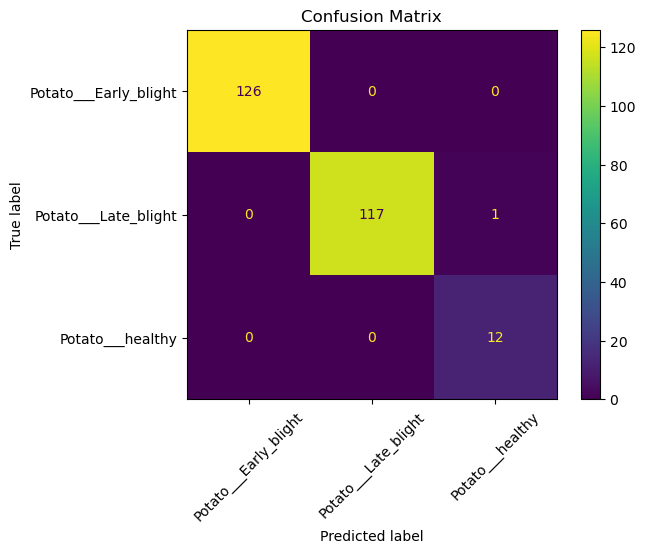

In [102]:


# Get true and predicted labels
y_true, y_pred, class_labels = get_true_and_pred_labels(model, test_ds, class_labels)

# Evaluate the model performance
evaluate_model(y_true, y_pred, class_labels)
